This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [ ]:
#!pip install keras keras-hub --upgrade -q

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Timeseries forecasting

이 장에서는 다음 내용을 다룹니다.

* **시계열 분석**을 위한 머신러닝 개요
* **순환 신경망(RNN)** 이해
* RNN을 활용한 **온도 예측 예제** 적용
---
이 장에서는 **시간적 순서가 매우 중요한 시계열 데이터**를 다룹니다. 특히 가장 흔하고 가치 있는 시계열 분석 작업인 예측에 초점을 맞출 것입니다. **최근 과거 데이터를 활용하여 가까운 미래를 예측하는 것**은 **에너지 수요 예측, 재고 관리, 날씨 예보** 등 다양한 분야에서 매우 강력한 기능입니다.

### Different kinds of timeseries tasks

시계열 데이터는 **주식의 일일 가격, 도시의 시간별 전력 소비량, 상점의 주간 매출**처럼 **일정한 간격으로 측정된 모든 데이터**를 의미합니다. 시계열 데이터는 **지진 활동, 강 어류 개체 수 변화, 특정 지역의 날씨**와 같은 자연 현상부터 **웹사이트 방문자 수, 국가 GDP, 신용카드 거래량**과 같은 인간 활동 패턴에 이르기까지 우리 주변 어디에나 존재합니다. 지금까지 접해온 데이터 유형과는 달리, 시계열 데이터를 다루려면 시스템의 역학, 즉 주기적인 순환, 시간 경과에 따른 추세, 규칙적인 양상, 그리고 갑작스러운 변동을 이해해야 합니다.

시계열 데이터와 관련된 가장 일반적인 작업은 단연 **예측**입니다. 즉, **시계열 데이터에서 다음에 어떤 일이 일어날지 예측하는 것**입니다. 예를 들어, 몇 시간 앞의 전력 소비량을 예측하여 수요를 예측하고, 몇 달 앞의 매출을 예측하여 예산을 계획하고, 며칠 앞의 날씨를 예측하여 일정을 계획할 수 있습니다. 이 장에서는 바로 이러한 예측에 초점을 맞춥니다. 하지만 시계열 데이터를 활용할 수 있는 방법은 실제로 매우 다양합니다. 예를 들어 다음과 같은 작업이 가능합니다.

* **이상 탐지** - 연속적인 데이터 스트림에서 비정상적인 상황을 감지합니다. 회사 네트워크에서 비정상적인 활동이 감지되었나요? 공격자일 가능성이 있습니다. 제조 라인에서 비정상적인 수치가 측정되었나요? 사람이 직접 확인해야 할 시점입니다. 이상 탐지는 일반적으로 비감독 학습을 통해 수행됩니다. 어떤 유형의 이상을 찾아야 하는지 알 수 없는 경우가 많기 때문에 특정 이상 사례로 모델을 학습시킬 수 없기 때문입니다.
* **분류** - 시계열 데이터에 하나 이상의 범주형 레이블을 할당합니다. 예를 들어 웹사이트 방문자의 활동 시계열 데이터가 주어졌을 때, 방문자가 봇인지 사람인지 분류할 수 있습니다.
* **이벤트 탐지** - 연속적인 데이터 스트림에서 특정 예상 이벤트의 발생을 식별합니다. 특히 유용한 응용 분야는 "핫워드 탐지"입니다. 모델이 오디오 스트림을 모니터링하여 "OK, Google" 또는 "Hey, Alexa"와 같은 발화를 감지하는 것입니다.

이 장에서는 순환 신경망(RNN)과 이를 시계열 예측에 적용하는 방법에 대해 알아봅니다.

### A temperature forecasting example

이 장 전체에 걸쳐 모든 코드 예제는 하나의 문제, 즉 건물의 옥상에 설치된 센서 세트로 **최근 과거에 기록된 대기압, 습도 등의 시간별 측정값 시계열을 기반으로 24시간 후의 온도를 예측하는 문제**를 다룹니다. 보시다시피, 이는 상당히 어려운 문제입니다!

이 온도 예측 작업을 통해 시계열 데이터가 지금까지 접해본 데이터 세트와 근본적으로 어떻게 다른지, **밀집 연결 네트워크와 컨볼루션 네트워크가 시계열 데이터 처리에 적합하지 않다**는 점, 그리고 이러한 유형의 문제에 특히 뛰어난 새로운 머신 러닝 기법인 **순환 신경망(RNN)을 소개**하겠습니다.

독일 예나에 있는 막스 플랑크 생지화학 연구소의 기상 관측소에서 기록된 기상 시계열 데이터 세트를 사용하겠습니다.[1] 이 데이터 세트에는 **온도, 대기압, 습도, 풍향 등 14가지 변수가 수년간 10분 간격으로 기록**되어 있습니다. 원본 데이터는 2003년까지 거슬러 올라가지만, 우리가 다운로드할 데이터는 **2009년부터 2016년까지**로 제한됩니다.

먼저 데이터를 다운로드하고 압축을 해제해 보겠습니다.

In [ ]:
# Doesn't work on Window
#!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
#!unzip jena_climate_2009_2016.csv.zip

In [51]:
import tensorflow as tf

zip_path = tf.keras.utils.get_file(
    "jena_climate_2009_2016.csv.zip",
    origin="https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip",
    extract=True,
    cache_dir=".",
    cache_subdir=""
)

In [53]:
zip_path

'.\\jena_climate_2009_2016_extracted'

데이터를 살펴보겠습니다.

이 명령은 **420,451줄의 데이터**(각 줄은 시간 단계, 즉 **날짜와 14개의 날씨 관련 값**에 대한 기록)와 다음과 같은 헤더를 출력합니다.

In [90]:
import os

fname = os.path.join(zip_path,"jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


이제 420,451개의 모든 데이터 행을 **NumPy 배열로 변환**합니다. 하나는 **온도(섭씨)를 저장하는 배열**이고, 다른 하나는 **나머지 데이터(미래 온도를 예측하는 데 사용할 특징)를 저장하는 배열**입니다. **"날짜 및 시간" 열은 제외**합니다.

In [94]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]   # 2-nd in the 14 features
    raw_data[i, :] = values[:]

그림 13.1은 시간에 따른 온도(섭씨)의 변화를 나타낸 그래프입니다. 이 그래프에서 온도의 연간 주기성을 명확하게 확인할 수 있으며, **데이터는 8년 동안의 변화**를 보여줍니다.

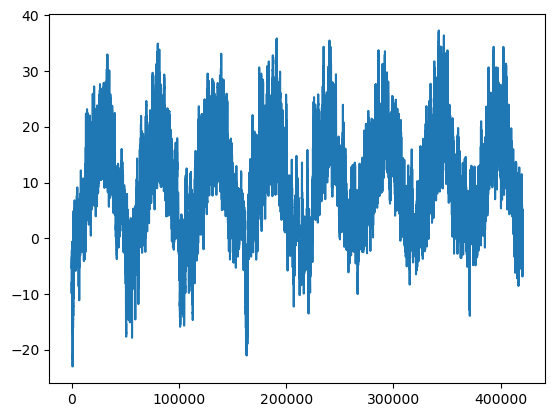

In [97]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

그림 13.2는 **처음 10일간의 온도 데이터**를 더 좁은 범위로 나타낸 그래프입니다. 데이터는 **10분마다 기록**되므로 **하루에 24 × 6 = 144개의 데이터 포인트**를 얻습니다.

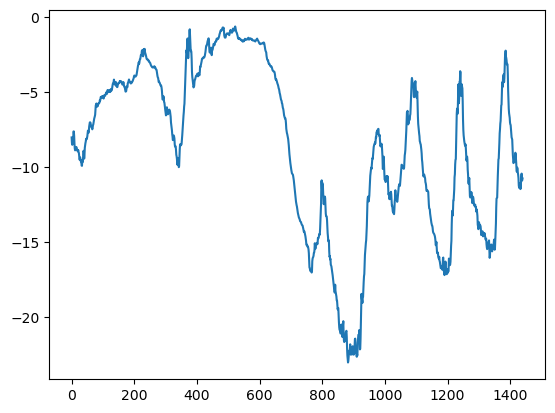

In [101]:
plt.plot(range(1440), temperature[:1440])

이 그래프에서 특히 지난 4일 동안 뚜렷한 일주기성을 확인할 수 있습니다. 또한 이 10일 주기는 상당히 추운 겨울철에 나타난 현상임이 분명합니다.
```
다양한 시간 척도에 걸친 주기성은 시계열 데이터의 중요하고 매우 흔한 속성입니다. 날씨, 쇼핑몰 주차 점유율, 웹사이트 트래픽, 식료품점 매출, 피트니스 트래커에 기록된 걸음 수 등 어떤 데이터를 보더라도 일별 주기와 연간 주기를 확인할 수 있습니다(사람이 생성한 데이터는 주간 주기도 나타내는 경향이 있습니다). 데이터를 분석할 때는 이러한 패턴을 찾아보는 것이 중요합니다.
```
저희 데이터셋을 예로 들어 **과거 몇 달간의 데이터를 바탕으로 다음 달 평균 기온을 예측**한다고 가정해 보겠습니다. 데이터의 주기성이 연간 단위로 안정적이기 때문에 문제는 **비교적 간단**합니다. 하지만 **일 단위로 데이터를 살펴보면 기온은 훨씬 더 불규칙적**으로 나타납니다. 과연 이 시계열 데이터는 일 단위로 예측 가능할까요? 함께 알아보겠습니다.

모든 실험에서 데이터의 **처음 50%는 학습**에, 다음 **25%는 검증**에, 그리고 나머지 **25%는 테스트**에 사용하겠습니다. **시계열 데이터를 다룰 때는 과거를 바탕으로 미래를 예측**하는 것이 목표이므로, **검증 및 테스트 데이터는 학습 데이터보다 최근의 데이터를 사용하는 것이 중요**합니다. 따라서 검증/테스트 데이터 분할은 이러한 시간적 순서를 반영해야 합니다. 시간 축을 반전시키면 오히려 문제가 훨씬 간단해지는 경우도 있습니다!

In [105]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


#### Preparing the data

문제의 정확한 정의는 다음과 같습니다. **지난 5일 동안 매시간 샘플링된 데이터가 주어졌을 때, 24시간 후의 온도를 예측할 수 있을까**요?

먼저, 신경망이 입력받을 수 있는 형식으로 데이터를 전처리해 보겠습니다. 데이터는 이미 수치형이므로 벡터화는 필요하지 않습니다. 하지만 **데이터의 각 시계열은 서로 다른 척도**를 가지고 있습니다(예를 들어, 대기압은 mbar 단위로 측정되며 약 1,000이고, H2OC는 밀리몰/몰 단위로 측정되며 약 3입니다). 따라서 **각 시계열을 독립적으로 정규화하여 모두 비슷한 척도의 작은 값을 갖도록** 하겠습니다. 처음 210,225개의 타임스텝을 훈련 데이터로 사용할 것이므로, 이 부분에 대해서만 평균과 표준 편차를 계산합니다.

In [109]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

다음으로, 지난 **5일간의 데이터 배치와 24시간 후의 목표 온도를 함께 생성하는 Dataset 객체**를 만들어 보겠습니다. **데이터셋의 샘플들은 중복성이 매우 높기 때문에**(샘플 N과 샘플 N+1은 대부분의 타임스텝을 공유함), 각 샘플마다 명시적으로 메모리를 할당하는 것은 비효율적입니다. 따라서 **원본 raw_data와 temperature 배열만 메모리에 유지하고 나머지는 메모리에 저장하지 않고, 필요에 따라 샘플을 동적으로 생성**합니다.

파이썬 제너레이터를 직접 작성하여 이 작업을 수행할 수도 있지만, **Keras에는 이러한 기능을 제공하는 내장 데이터셋 유틸리티(timeseries_dataset_from_array())가** 있으므로 이를 활용하면 시간을 절약할 수 있습니다. 이 유틸리티는 일반적으로 모든 종류의 시계열 예측 작업에 사용할 수 있습니다.

**timeseries_dataset_from_array() 함수 이해하기**

timeseries_dataset_from_array() 함수의 작동 방식을 이해하기 위해 간단한 예제를 살펴보겠습니다. 기본적으로 시계열 데이터 배열(data 인자)을 제공하면, timeseries_dataset_from_array() 함수는 원본 시계열에서 추출한 윈도우(이하 "시퀀스")를 생성합니다.

예를 들어 data = [0 1 2 3 4 5 6]이고 **sequence_length=3**인 경우, timeseries_dataset_from_array() 함수는 다음과 같은 샘플을 생성합니다: [0 1 2], [1 2 3], [2 3 4], [3 4 5], [4 5 6].

timeseries_dataset_from_array() 함수에 target 배열을 전달할 수도 있습니다. **targets 배열의 첫 번째 요소는 data 배열에서 생성될 첫 번째 시퀀스에 대한 원하는 target 값과 일치**해야 합니다. 시계열 예측을 하려면 데이터에 사용한 배열과 동일한 배열을 목표값으로 사용하되, 일정 값만큼 오프셋하면 됩니다.

예를 들어, 데이터가 [0 1 2 3 4 5 6 ...]이고 시퀀스 길이가 3인 경우, 목표값으로 [3 4 5 6 ...]을 전달하여 시계열의 다음 단계를 예측하는 데이터셋을 만들 수 있습니다. 한번 시도해 보겠습니다.

In [112]:
import numpy as np
import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


`timeseries_dataset_from_array` 함수를 사용하여 학습, 검증, 테스트용 데이터셋 세 개를 생성합니다.

다음과 같은 파라미터 값을 사용합니다.

* `sampling_rate = 6` — **1시간마다 한 개의 데이터 포인트를 추출**합니다. 추출된 6개의 데이터 포인트 중 하나만 사용합니다.
* `sequence_length = 120` — **5일(120시간) 전까지의 데이터를 사용**합니다.
* `delay = sampling_rate * (sequence_length + 24 - 1)` — 각 시퀀스의 **목표값은 시퀀스 종료 후 24시간 후의 온도**입니다.

* `start_index = 0` 및 `end_index = num_train_samples` — 학습 데이터셋의 경우, 처음 50%의 데이터만 사용합니다.

* `start_index = num_train_samples` 및 `end_index = num_train_samples + num_val_samples` — 검증 데이터셋의 경우, 다음 25%의 데이터만 사용합니다.
start_index = num_train_samples + num_val_samples — 테스트 데이터셋의 경우, 나머지 샘플을 사용합니다.

In [115]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

각 데이터 세트는 (샘플, 목표) 튜플을 반환합니다. 여기서 **samples는 120시간 연속 입력 데이터를 포함하는 256개의 샘플 배치**이고, **targets는 이에 해당하는 256개의 목표 온도 배열**입니다. 샘플은 무작위로 섞이기 때문에 배치 내의 연속된 두 시퀀스(예: samples[0] 및 samples[1])가 반드시 시간적으로 가깝지는 않습니다.

In [119]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


#### A commonsense, non-machine-learning baseline

블랙박스 방식의 딥러닝 모델을 사용하여 온도 예측 문제를 해결하기 전에, 간단하고 상식적인 접근 방식을 시도해 보겠습니다. 이는 기본적인 타당성 검증 역할을 하며, 더 발전된 머신러닝 모델의 **유용성을 입증하기 위해 넘어서야 할 기준선을 설정**해 줄 것입니다. 이러한 상식적인 기준선은 아직 알려진 해결책이 없는 새로운 문제에 접근할 때 유용합니다. 대표적인 예로, 일부 클래스가 다른 클래스보다 훨씬 더 많이 나타나는 불균형 분류 작업을 들 수 있습니다. 데이터셋에 A 클래스 인스턴스가 90%, B 클래스 인스턴스가 10% 포함되어 있다면, 새로운 샘플이 주어졌을 때 항상 "A"라고 예측하는 것이 상식적인 분류 방법입니다. 이러한 분류기는 전체적으로 90%의 정확도를 가지며, 따라서 학습 기반 접근 방식은 유용성을 입증하기 위해 이 90%를 넘어서야 합니다. 때로는 이러한 기본적인 기준선을 넘어서는 것이 생각보다 어려울 수 있습니다.

이 경우, 온도 시계열은 연속적이라고 안전하게 가정할 수 있습니다(내일 온도는 오늘 온도와 비슷할 가능성이 높습니다). 또한 일주기성을 갖습니다. 따라서 **상식적인 접근 방식은 24시간 후의 온도가 현재 온도와 같을 것이라고 예측**하는 것입니다. 이제 **평균 절대 오차(MAE) 지표**를 사용하여 이 접근 방식을 평가해 보겠습니다. MAE는 다음과 같이 정의됩니다.

```
np.mean(np.abs(preds - targets))
```

다음은 평가 루프입니다.

In [127]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


이 상식적인 기준선은 검증에서 2.44도, 테스트에서 2.62도의 MAE를 달성했습니다. 즉, **24시간 후의 온도가 현재 온도와 같을 것이라고 항상 가정하면 평균적으로 2.5도의 오차가 발생**합니다. 아주 나쁜 수치는 아니지만, 이러한 휴리스틱에 기반한 날씨 예보 서비스를 운영하기에는 무리가 있습니다. 이제 딥러닝에 대한 지식을 활용하여 더 나은 결과를 내는 것이 관건입니다.

#### Let's try a basic machine learning model

머신러닝 접근 방식을 시도하기 전에 상식적인 기준선을 설정하는 것이 유용한 것처럼, RNN과 같이 복잡하고 계산 비용이 많이 드는 모델을 살펴보기 전에 **간단하고 저렴한 머신러닝 모델(예: 작고 밀집 연결된 네트워크)을 시도**해 보는 것이 유용합니다. 이렇게 하면 문제에 적용하는 추가적인 복잡성이 타당하고 실질적인 이점을 제공하는지 확인할 수 있습니다.

목록 13.10은 데이터를 평탄화한 후 **두 개의 Dense 레이어**를 통과시키는 완전 연결 모델을 보여줍니다. 마지막 Dense 레이어에 **활성화 함수가 없는 것**을 확인할 수 있는데, 이는 **회귀 문제에서 일반적**입니다. **손실 함수로는 MAE(평균 절대 오차) 대신 MSE(평균 제곱 오차)를 사용**하는데, MAE와 달리 MSE는 0을 중심으로 부드럽게 수렴하는 특성을 가지고 있어 경사 하강법에 유용하기 때문입니다. **MAE는 compile() 함수에 메트릭으로 추가하여 모니터링**할 것입니다.

In [130]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 11.5201 - mae: 2.6082 - val_loss: 9.9601 - val_mae: 2.4747
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 7.6731 - mae: 2.1825 - val_loss: 10.2819 - val_mae: 2.5236
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 7.0422 - mae: 2.0877 - val_loss: 10.6336 - val_mae: 2.5761
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 6.7024 - mae: 2.0345 - val_loss: 10.7842 - val_mae: 2.5826
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 6.4446 - mae: 1.9964 - val_loss: 10.8320 - val_mae: 2.5982
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6.2810 - mae: 1.9706 - val_loss: 11.0892 - val_mae: 2.6357
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 6.1741 - mae: 1.9542 - val_loss: 10.8936 - val_mae: 2.6018
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 6.0362 - mae: 1.9332 - val_loss: 11.2062 - val_mae: 2.6453
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/s

검증 및 훈련에 대한 손실 곡선을 표시해 보겠습니다(그림 13.3 참조).

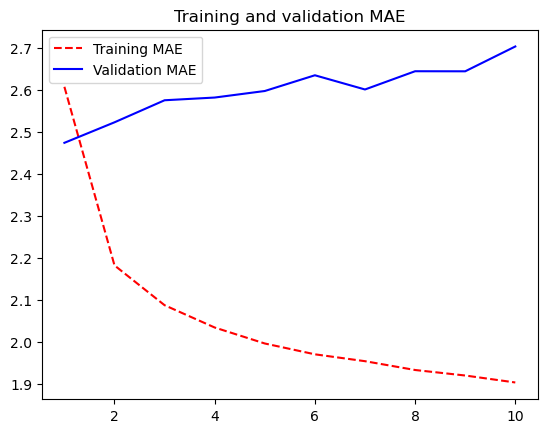

In [132]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

일부 검증 손실은 학습을 하지 않은 기준선에 근접하지만, 확실하지는 않습니다. 이는 애초에 기준선을 설정하는 것의 중요성을 보여줍니다. 기준선을 능가하는 것이 쉽지 않다는 것을 의미하기 때문입니다. 여러분의 상식에는 머신러닝 모델이 접근할 수 없는 귀중한 정보가 많이 담겨 있습니다.

간단하고 성능이 뛰어난 모델(상식 기준선)이 데이터에서 목표값으로 가는 길에 존재한다면, 왜 여러분이 훈련시키는 모델은 그 모델을 찾아내고 개선하지 못하는지 궁금할 수 있습니다. 그 이유는 여러분이 해법을 찾고자 하는 모델 공간, 즉 가설 공간이 여러분이 정의한 구성을 가진 모든 가능한 2계층 신경망의 공간이기 때문입니다. 상식 휴리스틱은 이 공간에 존재하는 수백만 개의 모델 중 하나일 뿐입니다. 마치 건초 더미에서 바늘을 찾는 것과 같습니다. 좋은 해법이 가설 공간에 기술적으로 존재한다고 해서 경사 하강법으로 반드시 찾아낼 수 있는 것은 아닙니다.

이는 머신러닝의 상당히 중요한 한계점 중 하나입니다. 학습 알고리즘이 특정 유형의 단순 모델을 찾도록 하드코딩되어 있지 않으면, 때로는 간단한 문제에 대한 간단한 해결책을 찾지 못할 수 있습니다. 그렇기 때문에 훌륭한 특징 엔지니어링과 관련 아키텍처 사전 정보를 활용하는 것이 필수적입니다. 모델에게 무엇을 찾아야 하는지 정확하게 알려줘야 합니다.

#### Let's try a 1D convolutional model

적절한 아키텍처 사전 정보를 활용하는 것에 대해 이야기하자면, 입력 시퀀스에 일주기적 특징이 있으므로 컨볼루션 모델이 적합할 수 있습니다. 시간적 컨볼루션 신경망(Temporal ConvNet)은 공간적 컨볼루션 신경망(Spatial ConvNet)이 이미지의 여러 위치에서 동일한 표현을 재사용하는 것처럼, 서로 다른 날짜에 걸쳐 동일한 표현을 재사용할 수 있습니다.

이미 알고 계시겠지만, 2D 그리드를 가로지르는 작은 창을 통해 입력을 처리하는 Conv2D 및 SeparableConv2D 레이어가 있습니다. 이러한 레이어에는 1D 및 3D 버전도 있습니다. Conv1D, SeparableConv1D, 그리고 Conv3D가 그것입니다.[2] Conv1D 레이어는 입력 시퀀스를 가로지르는 1D 창을 사용하고, Conv3D 레이어는 입력 볼륨을 가로지르는 3차 창을 사용합니다.

따라서 2D 컨볼루션 신경망과 엄밀히 유사한 **1D 컨볼루션 신경망을 구축**할 수 있습니다. **MaxPooling1D 레이어는 변환 불변성 가정을 따르는 모든 시퀀스 데이터에 매우 적합**합니다. (즉, 시퀀스 위로 윈도우를 이동하더라도 윈도우의 내용은 윈도우의 위치와 관계없이 동일한 속성을 유지해야 합니다.)

온도 예측 문제에 MaxPooling1D 레이어를 적용해 보겠습니다. 초기 윈도우 길이를 24로 설정하여 한 번에 24시간(한 주기)의 데이터를 살펴보겠습니다. MaxPooling1D 레이어를 통해 시퀀스를 다운샘플링하면서 윈도우 크기를 그에 따라 줄여나가겠습니다(그림 13.4).

In [137]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 22.7417 - mae: 3.6910 - val_loss: 14.9488 - val_mae: 3.0604
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 14.1485 - mae: 2.9774 - val_loss: 16.7787 - val_mae: 3.2418
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 12.8068 - mae: 2.8248 - val_loss: 14.0724 - val_mae: 2.9492
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 11.8969 - mae: 2.7190 - val_loss: 13.5583 - val_mae: 2.8998
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 11.1864 - mae: 2.6411 - val_loss: 13.1735 - val_mae: 2.8518
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 10.5693 - mae: 2.5656 - val_loss: 13.4445 - val_mae: 2.8833
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 10.2152 - mae: 2.5227 - val_loss: 13.3932 - val_mae: 2.8856
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 9.8711 - mae: 2.4795 - val_loss: 13.3651 - val_mae: 2.8814
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7

결과적으로 이 모델은 **밀집 연결 모델보다 성능이 훨씬 떨어져** 검증 MAE가 약 2.9도에 불과했는데, 이는 일반적인 기준선과는 거리가 멀다. 무엇이 문제였을까? 두 가지 이유가 있다.

첫째, 기상 데이터는 변환 불변성 가정을 완벽하게 만족시키지 못한다. 데이터에는 일주기성이 있지만, 아침 데이터는 저녁이나 한밤중 데이터와는 다른 특성을 보인다. 기상 데이터는 매우 특정한 시간 척도에서만 변환 불변성을 따른다.

둘째, 데이터의 순서가 매우 중요하다. 최근 데이터는 5일 전 데이터보다 다음 날 기온을 예측하는 데 훨씬 더 유용한 정보를 제공한다. 1D 컨볼루션 신경망은 이러한 사실을 활용할 수 없다. 특히, 최대 풀링과 전역 평균 풀링 레이어는 순서 정보를 상당 부분 파괴한다.

### Recurrent neural networks

완전 연결 방식이나 컨볼루션 방식 모두 좋은 결과를 보여주지는 못했지만, 그렇다고 머신 러닝이 이 문제에 적용될 수 없다는 의미는 아닙니다. **밀집 연결 방식은 먼저 시계열 데이터를 평탄화하여 입력 데이터에서 시간 개념을 제거**했습니다. **컨볼루션 방식은 데이터의 모든 부분을 동일하게 처리하고 풀링까지 적용하여 순서 정보를 파괴**했습니다. 이제 데이터를 있는 그대로, 즉 **인과 관계와 순서가 중요한 일련의 데이터**로 바라보겠습니다.

**이러한 용도에 특화된 신경망 아키텍처**가 있는데, 바로 **순환 신경망(RNN**)입니다. 그중에서도 특히 **장단기 메모리(LSTM) 레이어**는 오랫동안 널리 사용되어 왔습니다. 잠시 후 이러한 모델의 작동 방식을 살펴보겠지만, 먼저 LSTM 레이어를 실행해 보겠습니다.

In [140]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print("Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - loss: 44.5358 - mae: 4.9090 - val_loss: 17.0517 - val_mae: 3.0858
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 14.4102 - mae: 2.8798 - val_loss: 11.4751 - val_mae: 2.5942
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - loss: 11.2185 - mae: 2.5961 - val_loss: 10.5264 - val_mae: 2.5071
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 10.3206 - mae: 2.5006 - val_loss: 10.3442 - val_mae: 2.4588
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 9.9711 - mae: 2.4594 - val_loss: 9.6537 - val_mae: 2.4060
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - loss: 9.6515 - mae: 2.4177 - val_loss: 9.3634 - val_mae: 2.3744
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - loss: 9.5907 - mae: 2.4148 - val_loss: 9.1802 - val_mae: 2.3531
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 9.2375 - mae: 2.3718 - val_loss: 9.2915 - val_mae: 2.3713
Epoch 9/10
819/819 ━━━━━━━━━━━━━

그림 13.5는 결과를 보여줍니다. 훨씬 좋아졌습니다! **검증 MAE는 2.39도, 테스트 MAE는 2.55도**까지 낮아졌습니다. LSTM 기반 모델이 마침내 일반적인 기준선(비록 지금은 아주 근소한 ​​차이일지라도)을 능가할 수 있게 되었으며, 이는 이 작업에서 머신 러닝의 가치를 입증합니다.

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch13/lstm_model_metrics.ae01dd09.png" width="600"><br>Figure 13.5: Training and validation MAE on the Jena temperature forecasting task with an LSTM-based model. (Note that we omit epoch 1 on this graph because the high training MAE (7.75) at epoch 1 would distort the scale.)</p>

그렇다면 LSTM 모델이 밀집 연결 모델이나 컨볼루션 신경망보다 훨씬 뛰어난 성능을 보인 이유는 무엇일까요? 그리고 이 모델을 어떻게 더욱 개선할 수 있을까요? 이 질문에 답하기 위해 순환 신경망을 자세히 살펴보겠습니다.

#### Understanding recurrent neural networks

지금까지 살펴본 **밀집 연결 신경망이나 컨볼루션 신경망과 같은 모든 신경망의 주요 특징은 메모리가 없다는 것**입니다. 각 입력은 독립적으로 처리되며, 입력 간에 상태 정보가 저장되지 않습니다. 이러한 신경망에서 일련의 데이터 또는 시계열 데이터를 처리하려면 전체 시퀀스를 한 번에 네트워크에 제공해야 합니다. 즉, 하나의 데이터 포인트로 변환해야 합니다. 예를 들어, 밀집 연결 신경망 예시에서 했던 것처럼 5일치 데이터를 하나의 큰 벡터로 변환하여 한 번에 처리했습니다. 이러한 신경망을 **피드포워드 신경망**이라고 합니다.

반면, 지금 이 문장을 읽을 때는 단어 하나하나, 즉 눈동자의 움직임 하나하나를 처리하면서 앞의 내용을 기억합니다. 이러한 과정을 통해 문장이 전달하는 의미를 유동적으로 이해할 수 있습니다. **생물학적 지능은 과거 정보를 바탕으로 구축되고 새로운 정보가 들어올 때마다 지속적으로 업데이트되는 내부 모델을 유지하면서 정보를 점진적으로 처리**합니다.

순환 신경망(RNN)은 매우 단순화된 형태이긴 하지만 동일한 원리를 따릅니다. **RNN은 시퀀스 요소를 순회하면서 지금까지 처리한 내용과 관련된 정보를 담고 있는 상태를 유지함으로써 시퀀스를 처리**합니다. 즉, RNN은 내부 루프를 가진 신경망의 한 유형입니다(그림 13.6 참조).

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch13/simplernn.822d53ed.png" width="300"><br>Figure 13.6: A recurrent network: a network with a loop</p>

RNN의 상태는 서로 다른 두 개의 독립적인 시퀀스(예: 배치에 있는 두 개의 샘플)를 처리할 때마다 초기화됩니다. 따라서 하나의 시퀀스는 여전히 단일 데이터 포인트, 즉 네트워크에 대한 단일 입력으로 간주됩니다. 달라지는 점은 이 데이터 포인트가 더 이상 단일 단계로 처리되지 않고, 네트워크가 내부적으로 시퀀스 요소를 순회한다는 것입니다.

이러한 루프와 상태 개념을 명확히 하기 위해 **간단한 RNN의 순방향 전달**을 구현해 보겠습니다. 이 RNN은 입력으로 벡터 시퀀스를 받는데, 이를 (타임스텝, 입력 특징) 크기의 2차 텐서로 인코딩합니다. 이 **RNN은 타임스텝을 순회**하며, **각 타임스텝에서 현재 상태 t와 입력 t(형태는 (입력 특징,))를 고려하여 결합하여 출력 t**를 얻습니다. 그런 다음 **다음 단계의 상태를 이전 출력으로 설정**합니다. 첫 번째 타임스텝에서는 이전 출력이 정의되지 않았으므로 현재 상태가 없습니다. 이제 네트워크의 초기 상태라고 하는 모든 요소가 0인 벡터로 상태를 초기화하겠습니다.

의사 코드로 표현하면 이것이 RNN입니다.

```
# The state at t
state_t = 0
# Iterates over sequence elements
for input_t in input_sequence:
    output_t = f(input_t, state_t)
    # The previous output becomes the state for the next iteration.
    state_t = output_t
```

함수 f를 더욱 구체화할 수도 있습니다. **입력과 상태를 출력으로 변환하는 과정은 두 개의 행렬 W와 U, 그리고 바이어스 벡터로 매개변수화**됩니다. 이는 피드포워드 네트워크에서 밀집 연결 계층이 수행하는 변환과 유사합니다.

```
state_t = 0
for input_t in input_sequence:
    output_t = activation(dot(W, input_t) + dot(U, state_t) + b)
    state_t = output_t
```

이러한 개념을 완전히 명확하게 하기 위해 간단한 RNN의 순방향 전달에 대한 단순한 NumPy 구현을 작성해 보겠습니다.

In [152]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.concatenate(successive_outputs, axis=0)

간단히 말해서, **RNN은 이전 반복에서 계산된 값을 재사용하는 for 루프**일 뿐입니다. 물론 이 정의에 맞는 다양한 RNN을 만들 수 있지만, 이 예시는 가장 간단한 RNN 구현 중 하나입니다. RNN은 계단 함수로 특징지어지는데, 이 예시에서는 다음과 같은 함수를 사용합니다(그림 13.7 참조).

```
output_t = tanh(matmul(input_t, W) + matmul(state_t, U) + b)
```

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch13/unrolled_lstm_1.d9bee30c.png" width="600"><br>Figure 13.7: A simple RNN, unrolled over time</p>

이 예제에서 **최종 출력은 (timesteps, output_features) 형태의 2차 텐서**입니다. 여기서 각 timestep은 시간 t에서의 루프 출력을 나타냅니다. 출력 텐서의 각 timestep t에는 입력 시퀀스의 0부터 t까지의 시간 단계, 즉 전체 과거에 대한 정보가 포함되어 있습니다. 따라서 **많은 경우 전체 출력 시퀀스가 ​​필요하지 않고, 전체 시퀀스에 대한 정보를 이미 포함하고 있는 마지막 출력(루프 끝의 output_t)만** 있으면 됩니다.

#### A recurrent layer in Keras

방금 NumPy로 간단하게 구현한 프로세스는 실제 Keras 레이어, 즉 SimpleRNN 레이어에 해당합니다.

한 가지 작은 차이점이 있습니다. SimpleRNN은 다른 모든 Keras 레이어와 마찬가지로 시퀀스 배치를 처리하며, NumPy 예제처럼 단일 시퀀스를 처리하지 않습니다. 즉, 입력은 (시간 단계, 입력 특징) 형태가 아닌 (배치 크기, 시간 단계, 입력 특징) 형태를 가집니다. 초기 Input() 함수의 shape 인수를 지정할 때 timesteps 항목을 None으로 설정하면 네트워크가 임의의 길이의 시퀀스를 처리할 수 있다는 점에 유의하세요.

In [159]:
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

이는 특히 모델이 가변 길이 시퀀스를 처리하도록 설계된 경우에 유용합니다. 그러나 모든 시퀀스의 길이가 동일한 경우에는 입력 형태를 완전히 지정하는 것이 좋습니다. 이렇게 하면 `model.summary()`에서 출력 길이 정보를 표시할 수 있어 유용하며, 성능 최적화에도 도움이 될 수 있습니다(이 장의 뒷부분에 있는 "RNN 런타임 성능에 대한 참고 사항" 참조).

**Keras의 모든 순환 레이어(SimpleRNN, LSTM, GRU)는 두 가지 모드로 실행**될 수 있습니다. 
* **각 타임스텝에 대한 연속적인 출력 시퀀스 전체(형태는 (batch_size, timesteps, output_features)인 랭크 3 텐서)를 반환**하거나,
* **각 입력 시퀀스의 마지막 출력만(형태는 (batch_size, output_features)인 랭크 2 텐서) 반환**할 수 있습니다.

<p style="text-align:center">
<img src="https://miro.medium.com/max/892/0*meStrcl0-hSG2-lC.PNG" width="400"><br>Left: 마지막 출력만 반환, Right: 전체 시퀀스를 반환</p>

이 **두 모드는 생성자의 `return_sequences` 인수로 제어**됩니다. 이제 SimpleRNN을 사용하여 **마지막 타임스텝의 출력만 반환하는 예제**를 살펴보겠습니다.

In [162]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


다음 예제는 **전체 출력 시퀀스를 반환**합니다.

In [165]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


신경망의 표현력을 높이기 위해 **여러 개의 순환 레이어를 순차적으로 쌓는 것이 유용할 때**가 있습니다. 이러한 구성에서는 **모든 중간 레이어가 전체 출력 시퀀스를 반환**해야 합니다.

In [168]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

실제로 SimpleRNN 레이어를 사용하는 경우는 드뭅니다. 너무 단순해서 실질적으로 활용하기 어렵기 때문입니다. 특히 **SimpleRNN에는 큰 문제**가 있습니다. 이론적으로는 **시간 t에서 여러 타임스텝 전에 입력된 정보를 유지할 수 있어야 하지만, 실제로는 이러한 장기적인 의존성을 학습하는 것이 불가능**합니다. 이는 **기울기 소실 문제** 때문인데, 이는 레이어가 많은 비순환 신경망(피드포워드 신경망)에서 관찰되는 현상과 유사합니다. 신경망에 레이어를 계속 추가할수록 결국 학습이 불가능해지는 것입니다. 이러한 현상의 이론적 원인은 1990년대 초 Hochreiter, Schmidhuber, Bengio에 의해 연구되었습니다.[3]

다행히 Keras에는 SimpleRNN 외에도 **이러한 문제를 해결하기 위해 설계된 LSTM과 GRU라는 두 가지 순환 레이어**가 있습니다.

이제 **LSTM 레이어**를 살펴보겠습니다. 기본이 되는 장단기 메모리(LSTM) 알고리즘은 1997년 Hochreiter와 Schmidhuber에 의해 개발되었습니다.[4] 이는 기울기 소실 문제에 대한 그들의 연구의 결실입니다.

이 레이어는 여러분이 이미 알고 있는 SimpleRNN 레이어의 변형으로, 여러 타임스텝에 걸쳐 정보를 전달하는 방법을 추가합니다. **처리 중인 시퀀스와 평행하게 작동하는 컨베이어 벨트를 상상**해 보세요. 시퀀스의 정보는 언제든지 컨베이어 벨트에 올라타 나중 타임스텝으로 이동한 다음, 필요할 때 손상되지 않고 다시 내려올 수 있습니다. 이것이 바로 LSTM이 하는 일입니다. **정보를 나중에 사용하기 위해 저장함으로써 처리 과정에서 오래된 신호가 점차 사라지는 것을 방지**합니다. 이는 9장에서 배웠던 잔여 연결(residual connections)을 떠올리게 합니다. 거의 같은 개념입니다.

이 과정을 자세히 이해하기 위해 SimpleRNN 셀(그림 13.8 참조)부터 시작해 보겠습니다. 가중치 행렬이 많을 것이므로 출력 시 셀에서 W 및 U 행렬에 문자 'o'(Wo 및 Uo)를 사용하여 인덱싱하십시오.

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch13/unrolled_lstm_1.d9bee30c.png" width="600"><br>Figure 13.8: The starting point of an LSTM layer: a SimpleRNN</p>

이 그림에 **시간 단계를 넘나들며 정보를 전달하는 추가적인 데이터 흐름을 더해** 보겠습니다. **각 시간 단계에서의 값을 Ct**라고 하고, 여기서 C는 캐리(carry)를 의미합니다. 이 정보는 셀에 다음과 같은 영향을 미칩니다. **입력 연결 및 순환 연결과 결합**되고(밀집 변환: 가중 행렬과의 내적, 편향 추가, 활성화 함수 적용을 통해), **다음 시간 단계로 전달되는 상태에 영향**을 미칩니다(활성화 함수 및 곱셈 연산을 통해). 개념적으로, 캐리 데이터 흐름은 다음 출력과 다음 상태를 조절하는 방법입니다(그림 13.9 참조). 지금까지는 간단합니다.

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch13/unrolled_lstm_2.4145ecdf.png" width="600"><br>Figure 13.9: Going from a SimpleRNN to an LSTM: adding a carry track</p>

이제 미묘한 부분입니다. 캐리 데이터 흐름의 다음 값이 계산되는 방식입니다. 여기에는 세 가지 변환이 포함됩니다. 이 세 가지 변환 모두 SimpleRNN 셀의 형태를 하고 있습니다.

```
y = activation(dot(state_t, U) + dot(input_t, W) + b)
```

하지만 세 가지 변환 모두 각각 고유한 가중치 행렬을 가지고 있으며, 이 행렬은 i, f, k라는 문자로 인덱싱됩니다. 지금까지 작성한 내용은 다음과 같습니다(다소 임의적으로 보일 수 있지만, 이해해 주시기 바랍니다).

```
output_t = activation(dot(state_t, Uo) + dot(input_t, Wo) + dot(C_t, Vo) + bo)
i_t = activation(dot(state_t, Ui) + dot(input_t, Wi) + bi)
f_t = activation(dot(state_t, Uf) + dot(input_t, Wf) + bf)
k_t = activation(dot(state_t, Uk) + dot(input_t, Wk) + bk)
```

새로운 올림 상태(다음 c_t)는 i_t, f_t, k_t를 조합하여 얻습니다.

```
c_t+1 = i_t * k_t + c_t * f_t
```

그림 13.10에 표시된 대로 이것을 추가하세요. 그러면 끝입니다. 그다지 복잡하지 않죠. 단지 약간 복잡할 뿐입니다.

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch13/unrolled_lstm_3.1f68b33f.png" width="600"><br>Figure 13.10: Anatomy of an LSTM</p>

철학적인 관점에서 보자면, 이러한 연산들이 각각 어떤 역할을 하는지 해석해 볼 수 있습니다. 예를 들어, **c_t와 f_t를 곱하는 것은 캐리 데이터 흐름에서 불필요한 정보를 의도적으로 제거하는 방법**이라고 해석할 수 있습니다. 한편, **i_t와 k_t는 현재 정보를 제공하여 캐리 트랙을 새로운 정보로 업데이트**합니다. 하지만 결국 이러한 해석은 큰 의미가 없습니다. 왜냐하면 이러한 연산들이 실제로 하는 일은 연산을 매개변수화하는 가중치의 내용에 따라 결정되고, **가중치는 매 훈련 라운드마다 처음부터 다시 학습되기 때문에 특정 연산에 특정한 목적을 부여하는 것은 불가능**하기 때문입니다. (앞서 설명한) RNN 셀의 명세는 가설 공간, 즉 훈련 중에 좋은 모델 구성을 탐색하는 공간을 결정하지만, 셀이 실제로 무엇을 하는지는 결정하지 않습니다. 셀의 동작은 셀 가중치에 달려 있습니다. 동일한 셀이라도 가중치가 다르면 매우 다른 동작을 할 수 있습니다. 따라서 RNN 셀을 구성하는 연산들의 조합은 공학적인 설계라기보다는 탐색에 대한 제약 조건들의 집합으로 해석하는 것이 더 적절합니다.

이러한 제약 조건의 선택, 즉 RNN 셀을 어떻게 구현할 것인지에 대한 문제는 인간 엔지니어보다는 유전 알고리즘이나 강화 학습과 같은 최적화 알고리즘에 맡기는 것이 더 타당하다고 볼 수 있습니다. 미래에는 이러한 방식으로 모델을 구축하게 될 것입니다. 요컨대, **LSTM 셀의 구체적인 아키텍처에 대해 이해할 필요는 없습**니다. 인간으로서 그것을 이해하는 것은 여러분의 역할이 아니기 때문입니다. **LSTM 셀의 목적, 즉 과거 정보를 나중에 다시 입력하여 기울기 소실 문제를 해결**하는 것만 기억하면 됩니다.

#### Getting the most out of recurrent neural networks

지금까지 여러분은 다음 내용을 학습했습니다.

* RNN이란 무엇이며 어떻게 작동하는지
* LSTM이란 무엇이며, 왜 일반 RNN보다 긴 시퀀스에서 더 나은 성능을 보이는지
* Keras RNN 레이어를 사용하여 시퀀스 데이터를 처리하는 방법
다음으로, 딥러닝 시퀀스 모델을 최대한 활용하는 데 도움이 되는 RNN의 고급 기능들을 살펴보겠습니다. 이 섹션을 마치면 Keras에서 순환 신경망을 사용하는 데 필요한 대부분의 내용을 이해하게 될 것입니다.

다음 내용을 다룹니다.

* **순환 드롭아웃(Recurrent dropout)** - 드롭아웃의 변형으로, 순환 레이어에서 과적합을 방지하는 데 사용됩니다.
* **순환 레이어 쌓기(Stacking recurrent layers)** - 모델의 표현력을 향상시키지만, 계산 부하가 증가합니다.
* **양방향 순환 레이어(Bidirectional recurrent layers)** - 동일한 정보를 순환 신경망에 서로 다른 방식으로 제공하여 정확도를 높이고 망각 문제를 완화합니다.

이러한 기술들을 사용하여 온도 예측 RNN을 개선해 보겠습니다.

#### Using recurrent dropout to fight overfitting

이 장 초반에 사용했던 LSTM 기반 모델로 돌아가 보겠습니다. 이 모델은 일반적인 기준선을 능가하는 성능을 보인 첫 번째 모델입니다. 학습 및 검증 곡선을 살펴보면, 유닛 수가 매우 적음에도 불구하고 모델이 빠르게 과적합되는 것을 알 수 있습니다. 몇 에포크가 지나면서 학습 손실과 검증 손실이 상당히 벌어지기 시작합니다. 이러한 현상을 해결하기 위한 고전적인 기법인 드롭아웃에 대해서는 이미 잘 알고 계실 것입니다. 드롭아웃은 레이어의 입력 유닛을 무작위로 0으로 설정하여 레이어가 노출되는 학습 데이터 내의 우연한 상관관계를 끊는 기법입니다. 하지만 순환 신경망에서 드롭아웃을 올바르게 적용하는 것은 간단한 문제가 아닙니다.

순환 레이어 앞에 드롭아웃을 적용하면 정규화에 도움이 되기보다는 학습을 방해한다는 사실은 오랫동안 알려져 왔습니다. 2015년, Yarin Gal은 베이지안 딥러닝에 대한 박사 학위 논문의 일환으로[5] 순환 신경망에서 드롭아웃을 올바르게 사용하는 방법을 제시했습니다. 즉, 타임스텝마다 무작위로 변하는 드롭아웃 마스크 대신, 매 타임스텝마다 동일한 드롭아웃 마스크(드롭되는 유닛의 동일한 패턴)를 적용해야 한다는 것입니다. 더 나아가, GRU 및 LSTM과 같은 레이어의 순환 게이트에 의해 형성된 표현을 정규화하기 위해, 레이어의 내부 순환 활성화에 시간적으로 일정한 드롭아웃 마스크(순환 드롭아웃 마스크)를 적용해야 합니다. 매 타임스텝마다 동일한 드롭아웃 마스크를 사용하면 네트워크가 학습 오류를 시간에 따라 적절하게 전파할 수 있습니다. 시간적으로 무작위적인 드롭아웃 마스크는 이러한 오류 신호를 방해하여 학습 과정에 악영향을 미칠 수 있습니다.

Yarin Gal은 Keras를 사용하여 연구를 수행했으며, 이 메커니즘을 Keras 순환 레이어에 직접 통합하는 데 기여했습니다. Keras의 모든 순환 레이어에는 두 개의 드롭아웃 관련 인자가 있습니다. 하나는 레이어의 입력 유닛에 대한 드롭아웃 비율을 지정하는 float 값인 `dropout`이고, 다른 하나는 순환 유닛에 대한 드롭아웃 비율을 지정하는 `recurrent_dropout`입니다. 첫 번째 LSTM 예제의 LSTM 레이어에 순환 드롭아웃을 추가하고 과적합에 어떤 영향을 미치는지 살펴보겠습니다.

드롭아웃 덕분에 정규화를 위해 네트워크 크기에 크게 의존할 필요가 없으므로, 유닛 수를 두 배로 늘린 LSTM 레이어를 사용하겠습니다. 이렇게 하면 표현력이 향상될 것으로 예상됩니다(드롭아웃이 없으면 이 네트워크는 바로 과적합되기 시작합니다. 직접 시도해 보세요). 드롭아웃으로 정규화된 네트워크는 완전히 수렴하는 데 시간이 훨씬 오래 걸리므로, 에포크 수를 다섯 배로 늘려 모델을 학습시키겠습니다.

In [182]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - loss: 33.6167 - mae: 4.2755 - val_loss: 11.6081 - val_mae: 2.6129
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 16.5152 - mae: 3.1520 - val_loss: 9.7342 - val_mae: 2.4213
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 15.2341 - mae: 3.0331 - val_loss: 9.4665 - val_mae: 2.3977
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 14.7096 - mae: 2.9758 - val_loss: 9.1041 - val_mae: 2.3488
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 14.2099 - mae: 2.9235 - val_loss: 9.0129 - val_mae: 2.3421
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 13.6537 - mae: 2.8682 - val_loss: 8.8283 - val_mae: 2.3056
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 13.2929 - mae: 2.8319 - val_loss: 8.7155 - val_mae: 2.2900
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 13.0000 - mae: 2.7995 - val_loss: 8.7858 - val_mae: 2.3018
Epoch 9/50
819/819 ━━━━━━━━━━━━

그림 13.11은 결과를 보여줍니다. 성공입니다! 처음 20 에포크 동안 과적합이 더 이상 발생하지 않습니다. **검증 MAE는 2.27도**(학습을 하지 않은 기준선 대비 7% 개선)까지, **테스트 MAE는 2.45도**(기준선 대비 6.5% 개선)까지 낮아졌습니다. 꽤 괜찮은 결과입니다.

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch13/lstm_dropout_model_metrics.a624dc88.png" width="600"><br>Figure 13.11: Training and validation loss on the Jena temperature forecasting task with a dropout-regularized LSTM</p>

**RNN 런타임 성능에 관하여**

이 장에서 다루는 모델처럼 매개변수가 매우 적은 순환 신경망 모델은 작은 행렬 곱셈만 포함하고, for 루프 때문에 일련의 곱셈 연산이 병렬화되기 어렵기 때문에 멀티코어 CPU에서 훨씬 빠른 속도를 보이는 경향이 있습니다. 하지만 규모가 큰 RNN은 GPU 런타임을 통해 성능 향상을 크게 기대할 수 있습니다.

GPU에서 기본 키워드 인수를 사용하여 Keras LSTM 또는 GRU 레이어를 실행하면, 해당 레이어는 NVIDIA에서 제공하는 고도로 최적화된 저수준 알고리즘 구현체인 cuDNN 커널을 사용하게 됩니다(이전 장에서 언급했습니다). cuDNN 커널은 일반적으로 장단점이 있습니다. 빠르지만 유연성이 부족합니다. 기본 커널에서 지원하지 않는 작업을 시도하면 성능이 급격히 저하되므로 NVIDIA에서 제공하는 기능만 사용해야 하는 경우가 많습니다. 예를 들어, LSTM 및 GRU cuDNN 커널은 순환 드롭아웃을 지원하지 않으므로, 레이어에 순환 드롭아웃을 추가하면 런타임이 일반 TensorFlow 구현으로 되돌아가게 됩니다. 이 일반 구현은 일반적으로 GPU에서 2~5배 느립니다(계산 비용은 동일하지만).

cuDNN을 사용할 수 없을 때 RNN 레이어의 속도를 높이는 방법으로 루프 언롤링을 시도해 볼 수 있습니다. for 루프 언롤링은 루프 자체를 제거하고 그 내용을 N번 인라인하는 것입니다. RNN의 for 루프의 경우, 언롤링을 통해 TensorFlow는 기본 계산 그래프를 최적화할 수 있습니다. 하지만 RNN의 메모리 사용량도 상당히 증가하므로, 비교적 작은 시퀀스(약 100단계 이하)에만 적합합니다. 또한, 모델의 타임스텝 수를 미리 알고 있는 경우에만(즉, 초기 Input()에 None 항목이 없는 형태를 전달하는 경우) 언롤링을 사용할 수 있습니다. 작동 방식은 다음과 같습니다.


In [184]:
# sequence_length cannot be None.
inputs = keras.Input(shape=(sequence_length, num_features))
# Passes unroll=True to enable unrolling
x = layers.LSTM(32, recurrent_dropout=0.2, unroll=True)(inputs)

#### Stacking recurrent layers

과적합은 더 이상 발생하지 않지만 성능 병목 현상에 직면한 것 같으면 네트워크의 용량과 표현력을 늘리는 것을 고려해야 합니다. 일반적인 머신러닝 워크플로에 대한 설명을 떠올려 보세요. 과적합이 주요 장애물이 될 때까지 모델의 용량을 늘리는 것이 일반적으로 좋은 방법입니다(드롭아웃 사용과 같은 과적합 완화를 위한 기본적인 조치를 이미 취했다고 가정할 때). 심각한 과적합이 발생하지 않는 한, 현재 모델은 용량이 부족한 상태일 가능성이 높습니다.

네트워크 용량 증가는 일반적으로 레이어의 유닛 수를 늘리거나 레이어를 추가하는 방식으로 이루어집니다. 순환 레이어를 쌓아 올리는 것은 더 강력한 순환 네트워크를 구축하는 고전적인 방법입니다. 예를 들어, 얼마 전까지만 해도 Google 번역 알고리즘은 7개의 대형 LSTM 레이어를 쌓아 올린 형태로 구현되었습니다. 이는 엄청난 규모입니다.

Keras에서 순환 레이어를 쌓아 올리려면 모든 중간 레이어는 마지막 타임스텝의 출력이 아닌 전체 출력 시퀀스(랭크 3 텐서)를 반환해야 합니다. 이미 배웠듯이, 이는 `return_sequences=True`로 지정함으로써 가능합니다.

다음 예제에서는 드롭아웃 정규화된 순환 레이어 두 개를 쌓아 보겠습니다. 이번에는 LSTM 대신 GRU 레이어를 사용해 보겠습니다. GRU(Gated Recurrent Unit)는 LSTM과 매우 유사하며, LSTM 아키텍처를 약간 단순화하고 간소화한 버전이라고 생각할 수 있습니다. GRU는 2014년 Cho 등이 소개했는데, 당시에는 규모가 작았던 연구 커뮤니티에서 순환 신경망에 대한 관심이 다시 높아지기 시작하던 시점이었습니다.[6]

In [186]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 100s 117ms/step - loss: 27.6912 - mae: 3.8914 - val_loss: 10.4572 - val_mae: 2.4586
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 91s 111ms/step - loss: 14.9756 - mae: 2.9907 - val_loss: 9.1466 - val_mae: 2.3310
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 88s 107ms/step - loss: 14.0613 - mae: 2.9053 - val_loss: 8.9127 - val_mae: 2.3158
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 90s 109ms/step - loss: 13.5274 - mae: 2.8457 - val_loss: 8.6463 - val_mae: 2.2773
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 101s 123ms/step - loss: 13.0606 - mae: 2.7939 - val_loss: 8.7218 - val_mae: 2.2872
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 97s 119ms/step - loss: 12.5392 - mae: 2.7429 - val_loss: 8.6980 - val_mae: 2.2891
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 87s 106ms/step - loss: 12.2447 - mae: 2.7135 - val_loss: 8.8268 - val_mae: 2.3078
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 87s 106ms/step - loss: 11.8932 - mae: 2.6728 - val_loss: 8.5554 - val_mae: 2.2635
Epoch 9/50
819/819 ━━

그림 13.12는 결과를 보여줍니다. **테스트 MAE는 2.39도(기준선 대비 8.8% 개선)를 달성**했습니다. 추가된 레이어가 결과를 약간 개선하기는 하지만, 극적인 변화는 아닙니다. 이 시점에서는 네트워크 용량 증가에 따른 효과가 점차 감소하는 추세일 수 있습니다.

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch13/stacked_gru_dropout_model_metrics.5bfbf251.png" width="600"><br>Figure 13.12: Training and validation loss on the Jena temperature forecasting task with a stacked GRU network</p>

#### Using bidirectional RNNs

이 섹션에서 소개할 마지막 기법은 양방향 RNN입니다. 양방향 RNN은 일반적인 RNN 변형으로, 특정 작업에서 일반 RNN보다 뛰어난 성능을 제공할 수 있습니다. 자연어 처리 분야에서 자주 사용되는데, 딥러닝의 만능 도구라고 할 수 있습니다.

RNN은 순서에 매우 민감합니다. 입력 시퀀스의 타임스텝을 순서대로 처리하기 때문에 타임스텝의 순서를 바꾸거나 반전시키면 RNN이 시퀀스에서 추출하는 표현이 완전히 달라질 수 있습니다. 바로 이 때문에 온도 예측 문제처럼 순서가 중요한 문제에서 RNN이 뛰어난 성능을 발휘하는 것입니다. 양방향 RNN은 RNN의 순서 민감성을 활용합니다. 즉, 여러분이 이미 잘 알고 있는 GRU와 LSTM 레이어와 같은 두 개의 일반 RNN을 사용하여 각각 입력 시퀀스를 한 방향(시간 순서와 역순)으로 처리한 다음, 그 결과를 병합합니다. 양방향으로 시퀀스를 처리함으로써 양방향 RNN은 단방향 RNN이 놓칠 수 있는 패턴을 포착할 수 있습니다.

놀랍게도, 이 섹션의 RNN 레이어들이 시간 순서대로(오래된 타임스텝부터) 시퀀스를 처리한 것은 임의적인 결정이었을지도 모릅니다. 적어도 지금까지는 이 결정에 대해 의문을 제기해 본 적이 없습니다. 만약 RNN들이 입력 시퀀스를 역순, 예를 들어 최신 타임스텝부터 처리했다면 충분히 좋은 성능을 보였을까요? 실제로 시도해 보고 어떤 결과가 나오는지 살펴보겠습니다. 입력 시퀀스의 시간 차원을 반전시킨 데이터 생성기 변형 코드를 작성하기만 하면 됩니다(마지막 줄을 yield samples[:, ::-1, :], targets로 바꾸세요).

이 섹션의 첫 번째 실험에서 사용했던 것과 동일한 LSTM 기반 모델을 학습시키면, 이러한 역순 LSTM은 일반적인 기준 모델보다도 훨씬 낮은 성능을 보일 것입니다. 이는 이 경우 시간 순서대로 처리하는 것이 접근 방식의 성공에 중요하다는 것을 시사합니다. 이는 지극히 당연한 결과입니다. 기본 LSTM 레이어는 일반적으로 먼 과거보다 최근 과거를 더 잘 기억하며, 당연히 최근의 날씨 데이터가 오래된 데이터보다 문제 해결에 더 효과적입니다(이것이 상식적인 기준선이 상당히 강력한 이유입니다). 따라서 시간 순서대로 처리된 레이어가 역순으로 처리된 레이어보다 성능이 뛰어날 수밖에 없습니다.

하지만 자연어 처리와 같은 다른 많은 문제에서는 그렇지 않습니다. **직관적으로 문장을 이해하는 데 있어 단어의 중요성은 문장 내 위치에 크게 좌우되지 않습니다**. 텍스트 데이터의 경우, 역순 처리는 시간 순서대로 처리하는 것만큼 효과적입니다. **텍스트를 거꾸로 읽어도 문제없이 읽을 수 있습니다(직접 시도해 보세요!)**. 언어 이해에 있어 단어 순서는 중요하지만, 어떤 순서를 사용하든 결정적인 요소는 아닙니다.

중요한 것은, **역순 시퀀스로 학습된 RNN은 원래 시퀀스로 학습된 RNN과는 다른 표현 방식을 학습**한다는 점입니다. 마치 현실 세계에서 시간이 거꾸로 흐른다면, 즉 첫날에 죽고 마지막 날에 태어났다면 우리의 정신 모델이 달라지는 것과 같습니다. **머신러닝에서 서로 다르면서도 유용한 표현 방식은 항상 활용할 가치가 있으며, 그 차이가 클수록 더욱 좋습니다**. 이러한 표현 방식은 데이터를 바라보는 새로운 관점을 제공하고, 다른 접근 방식으로는 놓쳤을 데이터의 측면을 포착하여 작업 성능을 향상시킬 수 있습니다. 이것이 바로 앙상블의 기본 개념이며, 18장에서 자세히 살펴보겠습니다.

양방향 RNN은 이러한 아이디어를 활용하여 시간 순서 RNN의 성능을 향상시킵니다. **양방향 RNN은 입력 시퀀스를 양방향으로 분석**하여(그림 13.13 참조) 잠재적으로 **더 풍부한 표현을 얻고, 시간 순서 버전만으로는 놓쳤을 수 있는 패턴을 포착**합니다.


<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch13/bidirectional_rnn.a38aaba4.png" width="400"><br>Figure 13.13: How a bidirectional RNN layer works</p>

케라스에서 **양방향 RNN을 생성하려면 `Bidirectional` 레이어를 사용**합니다. 이 레이어는 **첫 번째 인수로 순환 레이어 인스턴스**를 받습니다. `Bidirectional` 레이어는 이 순환 레이어의 두 번째 인스턴스를 별도로 생성하고, 하나는 입력 시퀀스를 시간 순서대로 처리하는 데 사용하고 다른 하나는 입력 시퀀스를 역순으로 처리하는 데 사용합니다. 온도 예측 문제를 통해 이를 직접 시도해 볼 수 있습니다.

In [189]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - loss: 30.8826 - mae: 4.0236 - val_loss: 13.4161 - val_mae: 2.8463
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - loss: 11.8243 - mae: 2.6766 - val_loss: 11.0362 - val_mae: 2.5780
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - loss: 10.0990 - mae: 2.4682 - val_loss: 10.2315 - val_mae: 2.4805
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 9.4735 - mae: 2.3915 - val_loss: 10.2115 - val_mae: 2.4897
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 8.7764 - mae: 2.2991 - val_loss: 10.0728 - val_mae: 2.4782
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 8.4290 - mae: 2.2568 - val_loss: 9.8260 - val_mae: 2.4489
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 8.2453 - mae: 2.2323 - val_loss: 9.5286 - val_mae: 2.4110
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 8.1360 - mae: 2.2138 - val_loss: 9.7173 - val_mae: 2.4477
Epoch 9/10
819/819 ━━━━━━━━━━━━━

일반 LSTM 레이어만큼 성능이 좋지 않다는 것을 알게 될 것입니다. 그 이유는 간단합니다. 모든 예측 능력은 네트워크의 시간 순서 부분에서 나와야 하는데, 시간 반대 방향 부분은 이 작업에서 성능이 현저히 떨어지기 때문입니다(이 경우 최근 과거가 먼 과거보다 훨씬 중요하기 때문입니다). 동시에 시간 반대 방향 부분이 네트워크의 용량을 두 배로 늘려 과적합이 훨씬 일찍 발생하게 만듭니다.

하지만 **양방향 RNN은 텍스트 데이터, 또는 순서가 중요하지만 어떤 순서를 사용하든 상관없는 모든 종류의 데이터에 매우 적합**합니다. 실제로 2016년에는 양방향 LSTM이 많은 자연어 처리 작업에서 최첨단 기술로 여겨졌습니다(15장에서 다룰 Transformer 아키텍처가 등장하기 전까지).

### Going even further

온도 예측 문제의 성능을 향상시키기 위해 시도해 볼 수 있는 다른 방법들은 많습니다.

* 스택형 구조에서 각 순환 레이어의 유닛 수와 드롭아웃 값을 조정해 보세요. 현재 설정값들은 임의적인 경우가 많아 최적의 성능을 내지 못할 가능성이 높습니다.
* Adam 옵티마이저의 학습률을 조정하거나 다른 옵티마이저를 사용해 보세요.
* 순환 레이어 위에 단일 Dense 레이어 대신 여러 개의 Dense 레이어를 쌓아 회귀 분석기로 사용해 보세요.
* 모델 입력 데이터를 개선해 보세요. 더 길거나 짧은 시퀀스를 사용하거나 샘플링 속도를 변경하거나 특징 엔지니어링을 시작해 보세요.
언제나 그렇듯이 딥러닝은 과학이라기보다는 예술에 가깝습니다. 특정 문제에서 어떤 방법이 효과가 있을지 없을지에 대한 가이드라인은 제공할 수 있지만, 궁극적으로 모든 데이터셋은 고유합니다. 다양한 전략을 직접 경험적으로 평가해야 합니다. 현재로서는 문제를 최적으로 해결하기 위해 정확히 무엇을 해야 하는지 미리 알려주는 이론은 없습니다. 반복적인 시도가 필수적입니다.

저희 경험상, 이 데이터셋으로는 학습을 하지 않은 기준선 대비 약 10% 정도 성능을 향상시키는 것이 최선입니다. 아주 훌륭한 결과는 아니지만, 이러한 결과는 충분히 이해할 만합니다. 넓은 지역에 걸쳐 다양한 위치의 데이터를 확보할 수 있다면 가까운 미래의 날씨를 매우 정확하게 예측할 수 있지만, 단일 위치의 측정값만으로는 예측이 매우 어렵기 때문입니다. 현재 위치의 날씨 변화는 주변 지역의 현재 날씨 패턴에 따라 달라집니다.


**시장과 머신러닝**

일부 독자분들은 여기서 소개한 기법들을 **주식 시장의 증권 가격(또는 환율 등)을 예측하는 문제에 적용해 보고 싶어 하실 것**입니다. 하지만 **시장은 날씨 패턴과 같은 자연 현상과는 통계적 특성이 매우 다릅**니다. **시장에서는 과거의 실적이 미래의 수익을 예측하는 좋은 지표가 될 수 없습**니다. 마치 백미러만 보고 운전하는 것과 같습니다. 반면 머신러닝은 날씨, 전력 소비량, 매장 방문객 수처럼 과거 데이터가 미래를 예측하는 데 유용한 데이터셋에 적용할 수 있습니다.

**모든 거래는 근본적으로 정보 차익거래라는 점**을 항상 기억해야 합니다. 즉, **다른 시장 참여자들이 갖지 못한 데이터나 통찰력을 활용하여 우위를 점하는 것**입니다. 잘 알려진 머신러닝 기법과 공개된 데이터를 이용해 시장을 이기려 하는 것은 사실상 막다른 길입니다. 다른 사람들보다 정보 우위를 확보할 수 없기 때문입니다. 시간과 자원을 낭비하고 아무런 성과도 얻지 못할 가능성이 큽니다.


### Summary

* 6장에서 배웠듯이, 새로운 문제에 접근할 때는 먼저 선택한 지표에 대한 상식적인 기준선을 설정하는 것이 좋습니다. 기준선이 없으면 실제 진전을 이루고 있는지 알 수 없습니다.
* 추가 비용을 정당화하기 위해 값비싼 모델보다 간단한 모델부터 먼저 시도해 보세요. 때로는 간단한 모델이 최선의 선택이 될 수 있습니다.
* 특히 시계열 데이터처럼 데이터 순서가 중요한 경우 순환 신경망(RNN)은 매우 적합하며, 시계열 데이터를 평탄화하는 모델보다 훨씬 뛰어난 성능을 보여줍니다. Keras에서 사용할 수 있는 두 가지 핵심 RNN 레이어는 LSTM 레이어와 GRU 레이어입니다.
* 순환 신경망에서 드롭아웃을 사용하려면 시정수 드롭아웃 마스크와 순환 드롭아웃 마스크를 사용해야 합니다. 이러한 기능은 Keras 순환 레이어에 내장되어 있으므로 순환 레이어의 `recurrent_dropout` 인수를 사용하기만 하면 됩니다.
* RNN을 쌓아서 사용하면 단일 RNN 레이어보다 더 뛰어난 표현력을 제공합니다. 또한 이러한 방법들은 훨씬 더 비싸기 때문에 항상 그만한 가치가 있는 것은 아닙니다. 복잡한 문제(예: 기계 번역)에서는 분명한 성능 향상을 제공하지만, 더 작고 간단한 문제에는 항상 적합하지 않을 수 있습니다.